# Self-Organizing Maps (Mega Case Study)

## Importing the libraries

In [16]:
!pip install minisom

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## Importing the dataset

In [18]:
dataset = pd.read_csv("Credit_Card_Applications.csv")
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

## Feature Scaling

In [19]:
from sklearn.preprocessing import MinMaxScaler
minmax = MinMaxScaler(feature_range = (0, 1))
X = minmax.fit_transform(X)

## Training the SOM

In [20]:
from minisom import MiniSom
som = MiniSom(x = 10, y = 10, input_len = 15, sigma = 1.0, learning_rate = 0.5)
som.random_weights_init(X)
som.train_random(data = X, num_iteration = 100)

## Visualizing the results

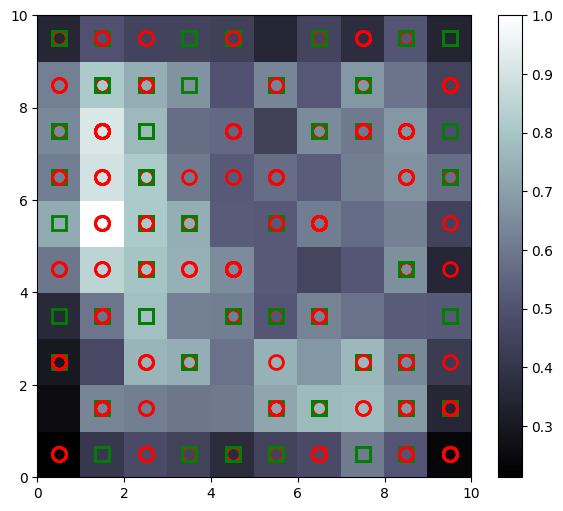

In [21]:
plt.figure(figsize = (7, 6))
plt.bone()

plt.pcolor(som.distance_map().T)
plt.colorbar()

marker = ['o', 's']
color = ['r', 'g']

for i, x in enumerate(X):
  w = som.winner(x)

  plt.plot(
      w[0] + 0.5,
      w[1] + 0.5,
      marker[y[i]],
      markeredgecolor = color[y[i]],
      markerfacecolor = 'None',
      markersize = 10,
      markeredgewidth = 2
  )

plt.show()

## Finding the frauds

In [23]:
mappings = som.win_map(X)
frauds = np.concatenate((mappings[(6, 1)], mappings[(7, 1)]), axis = 0)
frauds = minmax.inverse_transform(frauds)

In [24]:
print('Fraud Customer IDs')
for i in frauds[:, 0]:
  print(int(i))

Fraud Customer IDs
15777994
15704081
15677112
15697310
15722479
15810723
15730360
15766663
15703177
15733602
15728082
15693382
15752601
15740356
15793317
15649101


## Finding Accuracy using KMeans Clustering

In [25]:
from sklearn.cluster import KMeans

weights = som.get_weights()
grid_x, grid_y = weights.shape[0], weights.shape[1]

flat_weights = weights.reshape(grid_x * grid_y, -1)

kmeans = KMeans(n_clusters = 2, random_state = 42)
neuron_labels = kmeans.fit_predict(flat_weights)

labels = []
for x in X:
    r, c = som.winner(x)
    neuron_index = r * grid_y + c
    labels.append(neuron_labels[neuron_index])

## Graphically Visualizing

In [26]:
df = pd.DataFrame({"Actual": y, "Predicted": labels})
matrix = pd.crosstab(df['Actual'], df['Predicted'])

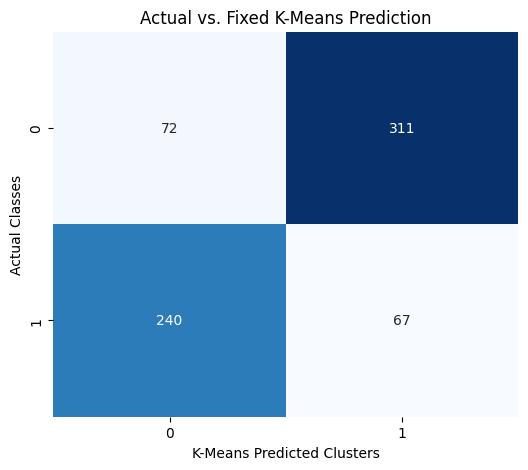

In [27]:
plt.figure(figsize = (6, 5))
sns.heatmap(matrix, annot = True, fmt = 'd', cmap = 'Blues', cbar = False)
plt.xlabel('K-Means Predicted Clusters')
plt.ylabel('Actual Classes')
plt.title('Actual vs. Fixed K-Means Prediction')
plt.show()

In [28]:
df

,Actual,Predicted
0,0,1
1,0,1
2,0,1
3,1,0
4,1,0
...,...,...
685,1,0
686,0,1
687,1,0
688,1,0


## Going from Unsupervised to Supervised Deep Learning

### Creating the Matrix of Features

In [36]:
customers = dataset.iloc[:, 1:].values

### Creating the Dependent Variable

In [37]:
is_fraud = np.zeros(len(dataset))
for i in range (len(dataset)):
  if dataset.iloc[i, 0] in frauds:
    is_fraud[i] = 1

### Feature Scaling

In [38]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
customers = sc.fit_transform(customers)

### Building the ANN

In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [40]:
model = Sequential()
model.add(Dense(units = 2, activation = 'relu'))
model.add(Dense(units = 1, activation = 'sigmoid'))

### Compiling the ANN

In [42]:
model.compile(
    optimizer = "adam",
    loss = "binary_crossentropy",
    metrics = ['accuracy']
)

### Training the ANN

In [43]:
model.fit(
    customers,
    is_fraud,
    batch_size = 1,
    epochs = 10
)

Epoch 1/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7188 - loss: 0.6819
Epoch 2/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9420 - loss: 0.3088
Epoch 3/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9739 - loss: 0.1854
Epoch 4/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9768 - loss: 0.1336
Epoch 5/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9768 - loss: 0.1058
Epoch 6/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9768 - loss: 0.0889
Epoch 7/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9768 - loss: 0.0771
Epoch 8/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9768 - loss: 0.0681
Epoch 9/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9768 - loss: 0.0621
Epoch 10/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9783 - loss: 0.0577


### Predicting the results

In [44]:
y_pred = model.predict(customers)
y_pred = np.concatenate((dataset.iloc[:, 0:1].values, y_pred), axis = 1)
y_pred = y_pred[y_pred[:, 1].argsort()]

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [45]:
print(y_pred)

[[1.57901130e+07 8.66691551e-07]
 [1.57938250e+07 4.18961499e-05]
 [1.56410070e+07 4.25078251e-05]
 ...
 [1.56933820e+07 5.54546893e-01]
 [1.57336020e+07 5.54957330e-01]
 [1.58107230e+07 6.03324771e-01]]
